# 🌡️ 气温回归预测 — 从零到深度学习

**目标**：根据历史气象数据，训练回归模型预测日最高温度（`actual` 列，华氏度）。

**数据集**：
| 文件 | 行数 | 年份 | 额外特征 | 用途 |
|------|------|------|----------|------|
| `temps_extended.csv` | 2191 | 2011–2017 | ws_1, prcp_1, snwd_1 | **训练集** |
| `temps.csv` | 348 | 2016 | — | **测试集** |

//

> ⚠️ **为什么这样划分？**  
> 1. `temps_extended.csv` 数据量大（2191行）、时间跨度长（2011–2017），带有风速/降水/积雪等气象特征，信息更丰富，适合**训练模型**。  
> 2. `temps.csv` 仅 2016 年 348 条记录，特征少，可作为**独立测试集**检验泛化能力。  
> 3. 两个 CSV 的 2016 年数据**同一日期数值不同**——说明来自不同数据源/气象站，没有包含关系，不会数据泄露。用 2011–2015 训练、2016 年 `temps.csv` 测试是安全的跨数据源泛化检验。  
> 4. 两者有共同特征列，可以保证模型输入一致。

## 📋 目录

1. 环境准备
2. 数据加载与探索
3. 数据集划分策略
4. 特征工程
5. 🧠 神经网络工作原理详解（从零实现）
   - 5.1 线性变换
   - 5.2 激活函数
   - 5.3 前向传播
   - 5.4 损失函数
   - 5.5 反向传播（梯度计算）
   - 5.6 梯度下降（参数更新）
   - 5.7 正则化（L2 + Dropout）
6. 🔧 从零构建神经网络（numpy）
7. 🚀 TensorFlow 实战
8. 参数调优实验
9. 模型评估
10. 🤔 思考题

---
## 1. 环境准备

In [1]:
import pandas as pd
import numpy as np

# — 可视化 —
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt
import seaborn as sns

# — sklearn 工具 —
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# — TensorFlow —
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# 设置随机种子，保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow 版本: {tf.__version__}")
print(f"Pandas 版本: {pd.__version__}")

TensorFlow 版本: 2.21.0
Pandas 版本: 2.3.2


---
## 2. 数据加载与探索

首先加载两个数据集，了解各自的结构和特征。

In [2]:
# 加载训练集（大数据、多特征）
df_train_all = pd.read_csv('../数据集/temps_extended.csv')
# 加载测试集（2016年、少特征）
df_test = pd.read_csv('../数据集/temps.csv')

print("=" * 60)
print("训练集 (temps_extended.csv):")
print(f"  形状: {df_train_all.shape[0]} 行 × {df_train_all.shape[1]} 列")
print(f"  年份范围: {df_train_all['year'].min()} – {df_train_all['year'].max()}")
print(f"  列名: {list(df_train_all.columns)}")
print()
print("测试集 (temps.csv):")
print(f"  形状: {df_test.shape[0]} 行 × {df_test.shape[1]} 列")
print(f"  年份: {df_test['year'].unique()}")
print(f"  列名: {list(df_test.columns)}")

训练集 (temps_extended.csv):
  形状: 2191 行 × 12 列
  年份范围: 2011 – 2017
  列名: ['year', 'month', 'day', 'weekday', 'ws_1', 'prcp_1', 'snwd_1', 'temp_2', 'temp_1', 'average', 'actual', 'friend']

测试集 (temps.csv):
  形状: 348 行 × 9 列
  年份: [2016]
  列名: ['year', 'month', 'day', 'week', 'temp_2', 'temp_1', 'average', 'actual', 'friend']


In [3]:
# 查看训练集年份分布
print("训练集年份分布:")
print(df_train_all['year'].value_counts().sort_index())
print(f"\ntemps.csv 年份分布:")
print(df_test['year'].value_counts().sort_index())

训练集年份分布:
year
2011    365
2012    365
2013    365
2014    365
2015    365
2016    365
2017      1
Name: count, dtype: int64

temps.csv 年份分布:
year
2016    348
Name: count, dtype: int64


In [4]:
# 🔍 关键发现：两表 2016 年数据不是同一份！
# 虽然是同一月日，但温度值不同 → 来自不同数据源/气象站，没有包含关系
ext_2016 = df_train_all[df_train_all['year'] == 2016].head(5)
print("temperatures_extended.csv 的 2016 年前 5 天:")
print(ext_2016[['month','day','actual','temp_1','temp_2']].to_string(index=False))
print("\ntemps.csv 的前 5 天:")
print(df_test[['month','day','actual','temp_1','temp_2']].head(5).to_string(index=False))
print("\n→ 同一日期 actual 值明显不同，证实两表是独立的不同数据源")

temperatures_extended.csv 的 2016 年前 5 天:
 month  day  actual  temp_1  temp_2
     1    1      46      42      42
     1    2      42      46      42
     1    3      40      42      46
     1    4      38      40      42
     1    5      46      38      40

temps.csv 的前 5 天:
 month  day  actual  temp_1  temp_2
     1    1      45      45      45
     1    2      44      45      44
     1    3      41      44      45
     1    4      40      41      44
     1    5      44      40      41

→ 同一日期 actual 值明显不同，证实两表是独立的不同数据源


In [5]:
# 训练集前 5 行
df_train_all.head()

,year,month,day,weekday,ws_1,prcp_1,snwd_1,temp_2,temp_1,average,actual,friend
0,2011,1,1,Sat,4.92,0.00,0,36,37,45.6,40,40
1,2011,1,2,Sun,5.37,0.00,0,37,40,45.7,39,50
2,2011,1,3,Mon,6.26,0.00,0,40,39,45.8,42,42
3,2011,1,4,Tues,5.59,0.00,0,39,42,45.9,38,59
4,2011,1,5,Wed,3.80,0.03,0,42,38,46.0,45,39


In [6]:
# 训练集信息
df_train_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2191 entries, 0 to 2190
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     2191 non-null   int64  
 1   month    2191 non-null   int64  
 2   day      2191 non-null   int64  
 3   weekday  2191 non-null   object 
 4   ws_1     2191 non-null   float64
 5   prcp_1   2191 non-null   float64
 6   snwd_1   2191 non-null   int64  
 7   temp_2   2191 non-null   int64  
 8   temp_1   2191 non-null   int64  
 9   average  2191 non-null   float64
 10  actual   2191 non-null   int64  
 11  friend   2191 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 205.5+ KB


In [7]:
# 训练集统计量
df_train_all.describe().round(2)

,year,month,day,ws_1,prcp_1,snwd_1,temp_2,temp_1,average,actual,friend
count,2191.00,2191.00,2191.00,2191.00,2191.00,2191.00,2191.00,2191.00,2191.00,2191.00,2191.00
mean,2013.50,6.52,15.71,7.37,0.12,0.01,61.17,61.18,60.29,61.18,60.31
std,1.71,3.45,8.80,3.15,0.25,0.15,13.09,13.08,10.73,13.08,15.87
min,2011.00,1.00,1.00,0.89,0.00,0.00,29.00,29.00,45.10,29.00,25.00
25%,2012.00,4.00,8.00,5.14,0.00,0.00,51.00,51.00,50.10,51.00,49.00
50%,2014.00,7.00,16.00,6.71,0.00,0.00,60.00,60.00,58.80,60.00,60.00
75%,2015.00,10.00,23.00,9.17,0.12,0.00,71.00,71.00,70.20,71.00,71.00
max,2017.00,12.00,31.00,21.25,2.20,3.00,96.00,96.00,77.40,96.00,97.00


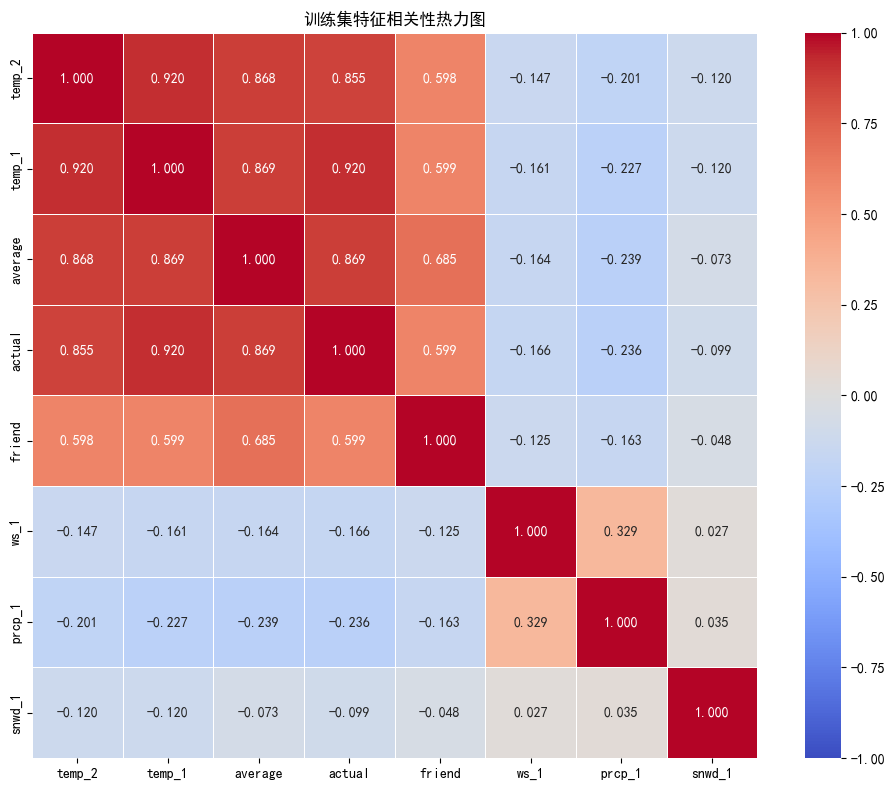

In [8]:
# 训练集特征相关性热力图
corr_cols = ['temp_2', 'temp_1', 'average', 'actual', 'friend', 'ws_1', 'prcp_1', 'snwd_1']
plt.figure(figsize=(10, 8))
sns.heatmap(df_train_all[corr_cols].corr(), annot=True, cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5, fmt='.3f')
plt.title('训练集特征相关性热力图')
plt.tight_layout()
plt.show()

---
## 3. 📊 数据集划分策略

### 为什么用 `temps_extended.csv` 做训练集、`temps.csv` 做测试集？

| 考量维度 | 训练集 (extended) | 测试集 (temps) |
|----------|-------------------|----------------|
| 数据量 | 2191 条 | 348 条 |
| 时间跨度 | 2011–2017（7年） | 2016（1年） |
| 特征丰富度 | 含风速/降水/积雪 | 仅基础温度特征 |
| 扮演角色 | 学习历史规律 | 检验泛化能力 |

**核心逻辑**：  
- 任务是**时序回归预测**，天然适合"用过去预测未来"的模式。  
- 将 2011–2015 年 + 2017 年数据用于训练，2016 年（`temps.csv`）作为"未来"测试集。  
- 虽然两个数据集特征列不完全相同，但它们有**共同特征**（temp_2, temp_1, average, friend, 星期/日期），我们只用共同特征建模，确保输入维度一致。

### 训练集取 2011–2015 年（排除 2016 年重合、2017年仅1行）

In [9]:
# 训练集：排除 2016 年（与测试集重合）和 2017 年（仅 1 行无意义），用 2011–2015 年
df_train = df_train_all[df_train_all['year'] <= 2015].copy()
print(f"训练集 (2011–2015): {df_train.shape[0]} 行")
print(f"测试集 (2016 年 temps.csv): {df_test.shape[0]} 行")
print(f"训练集年份: {sorted(df_train['year'].unique())}")

训练集 (2011–2015): 1825 行
测试集 (2016 年 temps.csv): 348 行
训练集年份: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]


---
## 4. 特征工程

分析两个数据集的特征列差异，确定**共同特征**，构建一致的输入。

In [10]:
# 对比列名差异
train_cols = set(df_train.columns)
test_cols = set(df_test.columns)
print(f"训练集独有列: {train_cols - test_cols}")
print(f"测试集独有列: {test_cols - train_cols}")
print(f"共同列: {train_cols & test_cols}")
print()
print(f"注意: extended 的星期列名是 'weekday'，temps 的是 'week'，内容相同但列名不同")

训练集独有列: {'weekday', 'prcp_1', 'snwd_1', 'ws_1'}
测试集独有列: {'week'}
共同列: {'actual', 'average', 'day', 'year', 'month', 'friend', 'temp_2', 'temp_1'}

注意: extended 的星期列名是 'weekday'，temps 的是 'week'，内容相同但列名不同


In [11]:
# — 提取目标变量 —
y_train = df_train['actual'].values
y_test = df_test['actual'].values

# — 数值共同特征 —
common_num_features = ['temp_2', 'temp_1', 'average', 'friend']
X_train_num = df_train[common_num_features].values
X_test_num = df_test[common_num_features].values

# — 处理星期特征（列名不同但内容相同）—
week_train = pd.get_dummies(df_train['weekday'])
week_test = pd.get_dummies(df_test['week'])

# 确保两者的 one-hot 列一致（按字母序排列）
all_weekdays = sorted(set(week_train.columns) | set(week_test.columns))
for wd in all_weekdays:
    if wd not in week_train.columns:
        week_train[wd] = 0
    if wd not in week_test.columns:
        week_test[wd] = 0
week_train = week_train[all_weekdays]
week_test = week_test[all_weekdays]

# — 时间特征（年月日可以编码季节性信息）—
# 月：周期编码 sin/cos，因为 1 月和 12 月在年周期上是相邻的
month_train = df_train['month'].values
month_test = df_test['month'].values
month_sin_train = np.sin(2 * np.pi * month_train / 12)
month_cos_train = np.cos(2 * np.pi * month_train / 12)
month_sin_test = np.sin(2 * np.pi * month_test / 12)
month_cos_test = np.cos(2 * np.pi * month_test / 12)

# 日：周期编码
day_train = df_train['day'].values
day_test = df_test['day'].values
day_sin_train = np.sin(2 * np.pi * day_train / 31)
day_cos_train = np.cos(2 * np.pi * day_train / 31)
day_sin_test = np.sin(2 * np.pi * day_test / 31)
day_cos_test = np.cos(2 * np.pi * day_test / 31)

# — 合并所有特征 —
X_train = np.column_stack([
    X_train_num,
    week_train.values,
    month_sin_train, month_cos_train,
    day_sin_train, day_cos_train,
])
X_test = np.column_stack([
    X_test_num,
    week_test.values,
    month_sin_test, month_cos_test,
    day_sin_test, day_cos_test,
])

feature_names = (common_num_features + list(all_weekdays)
                 + ['month_sin', 'month_cos', 'day_sin', 'day_cos'])

print(f"训练集 X 形状: {X_train.shape}, y 形状: {y_train.shape}")
print(f"测试集 X 形状: {X_test.shape}, y 形状: {y_test.shape}")
print(f"特征列 ({len(feature_names)} 个): {feature_names}")

训练集 X 形状: (1825, 15), y 形状: (1825,)
测试集 X 形状: (348, 15), y 形状: (348,)
特征列 (15 个): ['temp_2', 'temp_1', 'average', 'friend', 'Fri', 'Mon', 'Sat', 'Sun', 'Thurs', 'Tues', 'Wed', 'month_sin', 'month_cos', 'day_sin', 'day_cos']


In [12]:
# — 标准化 —
# 重要：仅用训练集计算均值和标准差，然后 transform 测试集，防止数据泄露
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"训练集均值 ≈ 0: {X_train_scaled.mean(axis=0).round(5)}")
print(f"训练集标准差 ≈ 1: {X_train_scaled.std(axis=0).round(5)}")
print(f"测试集标准差: {X_test_scaled.std(axis=0).round(3)}")

训练集均值 ≈ 0: [-0. -0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -0. -0.  0.  0.]
训练集标准差 ≈ 1: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
测试集标准差: [0.897 0.894 0.98  0.98  1.004 0.994 1.002 0.994 0.994 1.018 0.995 0.985
 1.013 1.004 0.995]


> **❓ 思考**：为什么标准化必须只用训练集统计量，不能用全部数据？  
> **答**：如果在标准化时使用了测试集的均值/标准差，就相当于让模型"偷看"了测试数据，造成**数据泄露**（data leakage）。模型评估就不再反映真实的泛化能力。

---
## 5. 🧠 神经网络工作原理详解

在调用 TensorFlow 高级 API 之前，我们先从数学底层理解神经网络的每一步。

一个神经网络的本质是：**多次线性变换 + 非线性激活函数的复合**。

### 5.1 线性变换（Linear Transformation）

神经网络最基础的运算单元是**全连接层（Dense Layer）**，其数学表达为：

$$\mathbf{Z} = \mathbf{X} \cdot \mathbf{W} + \mathbf{b}$$

- $\mathbf{X}$（$m \times n$）：$m$ 个样本，每个 $n$ 维特征
- $\mathbf{W}$（$n \times h$）：权重矩阵，$n$ 个输入连接到 $h$ 个神经元
- $\mathbf{b}$（$1 \times h$）：偏置，每个神经元一个
- $\mathbf{Z}$（$m \times h$）：线性变换后的输出

> **作用**：将输入特征**映射**到新的特征空间。如果不加激活函数，多层线性变换等价于一层 → 无法拟合非线性关系。

> **🔑 权重矩阵 = 神经元的集合**  
> 假设 $\mathbf{X}$ 是 1 条数据 $(1, 16)$，$\mathbf{W}$ 是 $(16, 64)$。那么 **W 的每一列就是一个神经元的全部权重**：第 1 列 = 第 1 个神经元从 16 个输入学到的 16 个系数。$64$ 列 = $64$ 个神经元同时计算。矩阵乘法 $\mathbf{X}\mathbf{W}$ 一次性算出 64 个神经元的激活值 $(1, 64)$。  
> ```
> x = [temp_2, temp_1, average, ..., day_cos]   形状: (1, 16)  一行数据
> W = [神经元1的权重, 神经元2的权重, ..., 神经元64的权重]  形状: (16, 64)
>                     ↑ 每列 = 一个神经元的16个权重系数
> z = x @ W = [激活值1, 激活值2, ..., 激活值64]   形状: (1, 64)
>                                                    64 = 64个神经元的输出
> ```

In [13]:
# — 演示：线性变换（单个神经元视角）—
# 假设输入特征 x1, x2，权重 w1, w2，偏置 b
def linear_transform(X, W, b):
    """线性变换: Z = X·W + b"""
    return np.dot(X, W) + b

# 造 3 个样本，2 维特征 → 1 个神经元的简单例子
X_demo = np.array([[1.0, 2.0],
                   [3.0, 4.0],
                   [5.0, 6.0]])
W_demo = np.array([[0.5],
                   [-0.3]])
b_demo = np.array([0.1])

Z_demo = linear_transform(X_demo, W_demo, b_demo)
print("X (3×2):\n", X_demo)
print("\nW (2×1):\n", W_demo)
print("\nb (1×1):\n", b_demo)
print("\nZ = X·W + b (3×1):\n", Z_demo)
print(f"\n验证第1个样本: 1.0×0.5 + 2.0×(-0.3) + 0.1 = {1.0*0.5 + 2.0*(-0.3) + 0.1}")

X (3×2):
 [[1. 2.]
 [3. 4.]
 [5. 6.]]

W (2×1):
 [[ 0.5]
 [-0.3]]

b (1×1):
 [0.1]

Z = X·W + b (3×1):
 [[2.77555756e-17]
 [4.00000000e-01]
 [8.00000000e-01]]

验证第1个样本: 1.0×0.5 + 2.0×(-0.3) + 0.1 = 2.7755575615628914e-17


### 5.2 激活函数（Activation Functions）

线性变换后再接一个**非线性函数**，才能让神经网络拟合任意复杂的函数。

| 激活函数 | 公式 | 值域 | 特点 |
|----------|------|------|------|
| **Sigmoid** | $\sigma(x) = \frac{1}{1+e^{-x}}$ | (0,1) | 平滑，但梯度易饱和（两端梯度≈0）|
| **Tanh** | $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$ | (-1,1) | 零中心，但仍有饱和问题 |
| **ReLU** | $\text{ReLU}(x) = \max(0, x)$ | [0, +∞) | 计算简单，不饱和，最常用 |

> **为什么 ReLU 最常用？**  
> 1. **计算快**：只需比较是否大于 0  
> 2. **缓解梯度消失**：正区间的导数恒为 1，深层网络梯度不会指数衰减  
> 3. **稀疏激活**：负值直接输出 0，部分神经元"关闭"，类似天然的正则化  

> **缺点**：负区间的导数为 0 会导致"神经元死亡"（用 LeakyReLU 缓解）

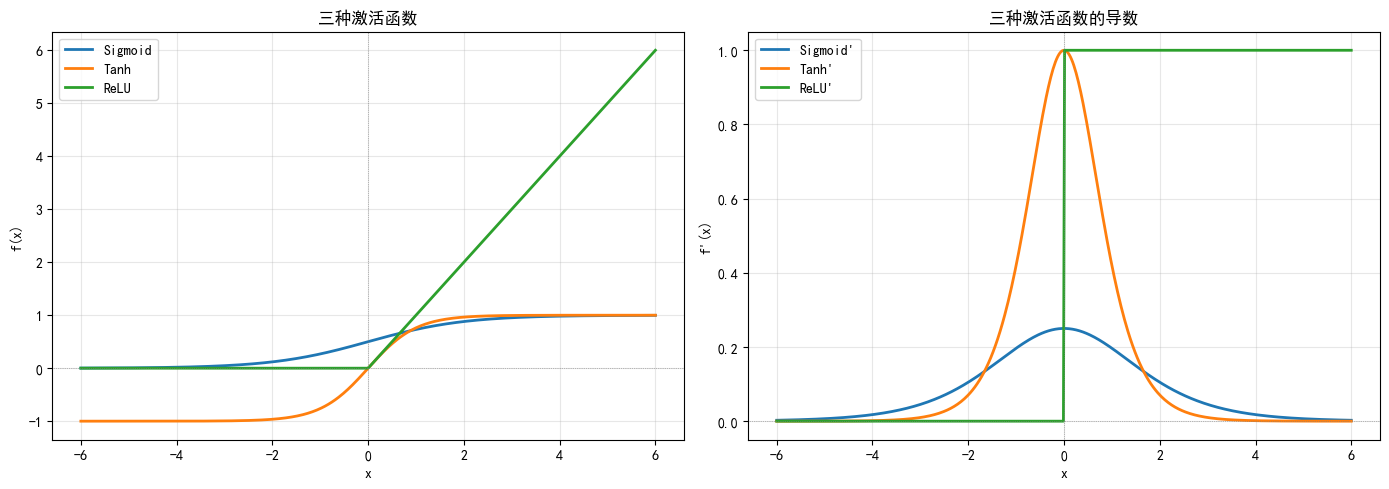

Sigmoid 导数最大值: 0.250
Tanh 导数最大值:    1.000
ReLU 导数（正区间）: 1.000


In [14]:
# — 画三种激活函数及其导数 —
x = np.linspace(-6, 6, 500)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh_derivative(x):
    return 1 - np.tanh(x) ** 2

def relu_derivative(x):
    return (x > 0).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 激活函数
axes[0].plot(x, sigmoid(x), label='Sigmoid', lw=2)
axes[0].plot(x, tanh(x), label='Tanh', lw=2)
axes[0].plot(x, relu(x), label='ReLU', lw=2)
axes[0].axhline(0, color='gray', linestyle=':', lw=0.5)
axes[0].axvline(0, color='gray', linestyle=':', lw=0.5)
axes[0].set_title('三种激活函数')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 导数
axes[1].plot(x, sigmoid_derivative(x), label="Sigmoid'", lw=2)
axes[1].plot(x, tanh_derivative(x), label="Tanh'", lw=2)
axes[1].plot(x, relu_derivative(x), label="ReLU'", lw=2)
axes[1].axhline(0, color='gray', linestyle=':', lw=0.5)
axes[1].axvline(0, color='gray', linestyle=':', lw=0.5)
axes[1].set_title('三种激活函数的导数')
axes[1].set_xlabel('x')
axes[1].set_ylabel("f'(x)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Sigmoid 导数最大值: {:.3f}".format(sigmoid_derivative(0)))
print("Tanh 导数最大值:    {:.3f}".format(tanh_derivative(0)))
print("ReLU 导数（正区间）: 1.000")

### 5.3 前向传播（Forward Propagation）

前向传播就是"输入 → 输出"的计算过程：

```
输入 X
  ↓ [Layer 1]
Z1 = X·W1 + b1        ← 线性变换
A1 = ReLU(Z1)         ← 激活函数（引入非线性）
  ↓ [Layer 2]
Z2 = A1·W2 + b2       ← 第二个线性变换
A2 = ReLU(Z2)         ← 第二个激活
  ↓ [输出层]
y_pred = A2·W3 + b3   ← 回归问题：输出层不用激活函数
```

> **为什么回归输出层不用激活函数？**  
> 回归需要预测任意连续的实数值（温度可以是 -10°F 到 120°F）。如果加了 Sigmoid，输出被限制在 (0,1) 之间；如果加了 ReLU，输出被限制在 [0, +∞)。不使用激活函数 = 线性输出，值域是 $(-∞, +∞)$。

> **🔑 数据形状在前向传播中的变化（以本项目为例）**  
> 假设一次传入 32 条数据（batch_size=32），每条 16 个特征：  
> ```
> 输入 X:        (32, 16)  ← 32条数据 × 16个特征
>   ↓ hidden_1:  (32, 16) × (16, 64) = (32, 64)  ← 中间有64个神经元
>   ↓ hidden_2:  (32, 64) × (64, 32) = (32, 32)  ← 压缩到32个神经元
>   ↓ hidden_3:  (32, 32) × (32, 16) = (32, 16)  ← 再压到16个
>   ↓ output:    (32, 16) × (16,  1) = (32,  1)  ← 32条预测温度
> ```
> **行数（32）始终不变，列数在不断变换。每层的权重矩阵形状是 $(输入维度, 神经元数)$，最后一层压成 1 列 = 1 个温度值。**

### 5.4 损失函数（Loss Function）

损失函数衡量"预测值"与"真实值"之间的差距，指导模型优化的方向。

#### 均方误差 MSE（Mean Squared Error）

$$L = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2$$

- $m$：样本数
- $y_i$：真实值
- $\hat{y}_i$：预测值

> **为什么回归问题用 MSE？**  
> 1. **可微**：MSE 处处可导，适合梯度下降  
> 2. **惩罚大误差**：平方操作让大误差被放得更大，模型更关注"离谱"的预测  
> 3. **凸性**：MSE 是凸函数，有唯一最小值  

> MAE（$\frac{1}{m}\sum|y_i - \hat{y}_i|$）也可以，MSE 对大误差更敏感，适合温度预测（我们不愿看到很大偏差）

In [15]:
# — 演示：MSE vs MAE 对异常值的敏感度 —
y_true = np.array([50, 52, 51, 50, 53, 51, 50, 52, 50, 51])  # 正常值
y_pred_good = np.array([50, 52, 51, 50, 53, 51, 50, 52, 50, 100])  # 含一个异常预测

mse = np.mean((y_true - y_pred_good) ** 2)
mae = np.mean(np.abs(y_true - y_pred_good))

print(f"当有一个预测值是 100（其他都很准）:")
print(f"  MSE = {mse:.1f}  ← 放大了 49° 的平方 = 2401")
print(f"  MAE = {mae:.1f}  ← 仅取绝对值 49")

当有一个预测值是 100（其他都很准）:
  MSE = 240.1  ← 放大了 49° 的平方 = 2401
  MAE = 4.9  ← 仅取绝对值 49


### 5.5 反向传播（Backward Propagation）

反向传播用**链式法则（Chain Rule）**计算损失函数对每个参数的梯度。

以 $L = \frac{1}{2}(y - \hat{y})^2$，$\hat{y} = W \cdot x + b$ 为例：

| 步骤 | 公式 | 含义 |
|------|------|------|
| ① 损失对预测 | $\frac{\partial L}{\partial \hat{y}} = -(y - \hat{y})$ | 预测偏多少，损失变化多大 |
| ② 预测对 W | $\frac{\partial \hat{y}}{\partial W} = x$ | W 变化时预测如何变 |
| ③ 链式 → dL/dW | $\frac{\partial L}{\partial W} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial W} = -(y - \hat{y}) \cdot x$ | 损失对 W 的最终梯度 |
| ④ 预测对 b | $\frac{\partial \hat{y}}{\partial b} = 1$ | b 变化时预测按 1:1 变 |
| ⑤ 链式 → dL/db | $\frac{\partial L}{\partial b} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial b} = -(y - \hat{y})$ | 损失对 b 的最终梯度 |

> **本质**：反向传播就是"误差信号"从输出层向输入层逐层传递，每层根据自己对该误差的"贡献"来调整参数。链式法则把复杂的复合函数拆成一步步的局部导数相乘。

> **关键导数**：
> - ReLU: $\frac{d}{dx}\max(0,x) = \begin{cases}1 & x > 0 \\ 0 & x \leq 0\end{cases}$  
> - MSE 损失: $\frac{d}{d\hat{y}}(y - \hat{y})^2 = -2(y - \hat{y})$

In [16]:
# — 演示：手动计算反向传播（单层网络，1 个神经元）—
print("=== 手算反向传播 ===\n")

# 假设一组数据和参数
x_demo = np.array([1.0, 2.0])       # 输入（2个特征）
y_demo = 5.0                         # 真实值
W_demo = np.array([0.5, -0.3])      # 权重
b_demo = 0.1                         # 偏置

# 前向传播
y_pred = np.dot(W_demo, x_demo) + b_demo
loss = 0.5 * (y_demo - y_pred) ** 2  # 0.5*MSE（方便求导消去 2）

print(f"y_pred = W·x + b = {W_demo}·{x_demo} + {b_demo} = {y_pred:.2f}")
print(f"真实值 y = {y_demo}")
print(f"Loss = 0.5 × ({y_demo} - {y_pred:.2f})² = {loss:.4f}\n")

# 反向传播（梯度计算）
dL_dy_pred = -(y_demo - y_pred)       # 损失对预测的梯度
dy_pred_dW = x_demo                   # 预测对 W 的梯度
dL_dW = dL_dy_pred * dy_pred_dW       # 链式法则 → 损失对 W 的梯度
dL_db = dL_dy_pred * 1                # 损失对 b 的梯度

print("反向传播:")
print(f"  dL/d(ypred) = -(y - ypred) = {dL_dy_pred:.4f}")
print(f"  d(ypred)/dW = x = {dy_pred_dW}")
print(f"  dL/dW = dL/d(ypred) × d(ypred)/dW = {dL_dW}")
print(f"  dL/db = dL/d(ypred) × 1 = {dL_db:.4f}")

print(f"\n解释: W 增加一点点 → 预测增加 x·ΔW → 损失变化 dL/dW·ΔW")

=== 手算反向传播 ===

y_pred = W·x + b = [ 0.5 -0.3]·[1. 2.] + 0.1 = 0.00
真实值 y = 5.0
Loss = 0.5 × (5.0 - 0.00)² = 12.5000

反向传播:
  dL/d(ypred) = -(y - ypred) = -5.0000
  d(ypred)/dW = x = [1. 2.]
  dL/dW = dL/d(ypred) × d(ypred)/dW = [ -5. -10.]
  dL/db = dL/d(ypred) × 1 = -5.0000

解释: W 增加一点点 → 预测增加 x·ΔW → 损失变化 dL/dW·ΔW


### 5.6 梯度下降（Gradient Descent）

有了梯度后，用**梯度下降**更新参数：

$$W := W - \eta \cdot \frac{\partial L}{\partial W}$$
$$b := b - \eta \cdot \frac{\partial L}{\partial b}$$

- $\eta$（学习率）：控制每步更新的步长

> **直觉**：梯度指向"损失函数增长最快的方向"。我们往**相反方向**走一小步，损失就会减小。

> **学习率的影响**：
> - 太小 → 收敛慢，可能陷入局部最优  
> - 太大 → 震荡甚至发散  
> - 合适 → 快速稳定收敛

C:\Users\8DA\AppData\Local\Temp\ipykernel_12404\1233630295.py:45: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\8DA\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


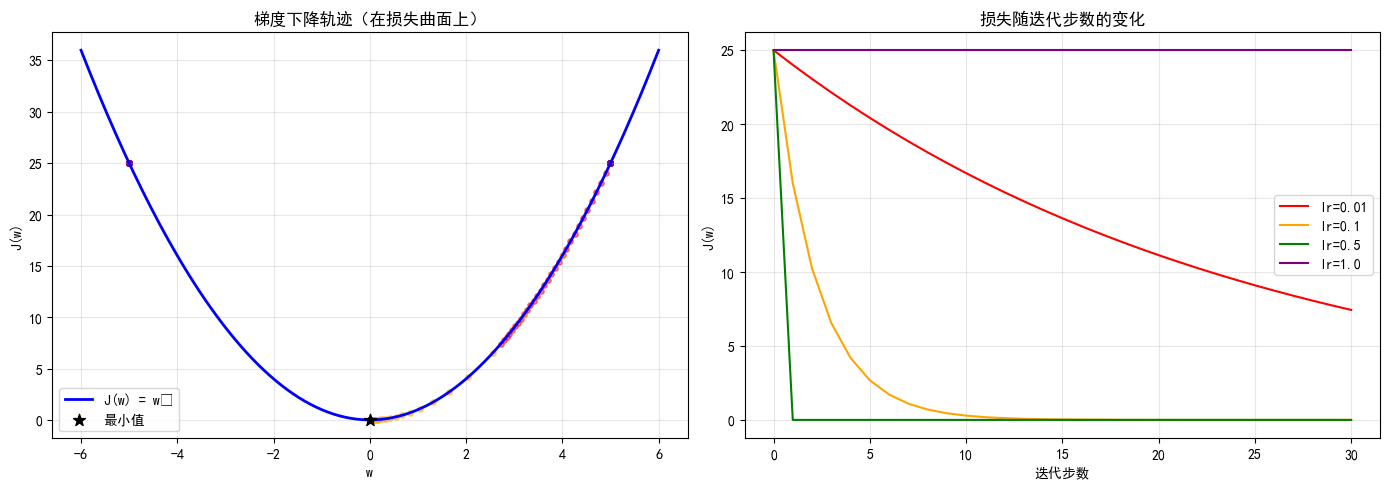

lr=0.01: 太慢，30步还没到0
lr=0.1:  合适，稳健收敛
lr=0.5:  较快，但略有震荡
lr=1.0:  发散！一步就跳过最小值到了对面


In [17]:
# — 演示：梯度下降的动态过程 —
# 用简单的二次函数 J(w) = w²（最小值在 w=0）来可视化
def loss_func(w):
    return w ** 2

def grad_func(w):
    return 2 * w

# 记录不同学习率的收敛过程
learning_rates = [0.01, 0.1, 0.5, 1.0]
w_init = 5.0
n_steps = 30

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 损失曲线
w_vals = np.linspace(-6, 6, 200)
axes[0].plot(w_vals, loss_func(w_vals), 'b-', lw=2, label='J(w) = w²')
colors = ['red', 'orange', 'green', 'purple']

for lr, color in zip(learning_rates, colors):
    w = w_init
    w_history = [w]
    for _ in range(n_steps):
        w = w - lr * grad_func(w)
        w_history.append(w)
    w_history = np.array(w_history)
    loss_history = loss_func(w_history)
    axes[0].scatter(w_history, loss_history, c=color, s=15, alpha=0.5)
    axes[1].plot(loss_history, c=color, lw=1.5, label=f'lr={lr}')

axes[0].scatter([0], [0], c='black', s=80, marker='*', zorder=5, label='最小值')
axes[0].set_xlabel('w')
axes[0].set_ylabel('J(w)')
axes[0].set_title('梯度下降轨迹（在损失曲面上）')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('迭代步数')
axes[1].set_ylabel('J(w)')
axes[1].set_title('损失随迭代步数的变化')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("lr=0.01: 太慢，30步还没到0")
print("lr=0.1:  合适，稳健收敛")
print("lr=0.5:  较快，但略有震荡")
print("lr=1.0:  发散！一步就跳过最小值到了对面")

### 5.7 正则化（Regularization）

正则化用来**防止过拟合**——模型在训练集上表现很好，但在测试集上表现很差。

#### 5.7.1 L2 正则化（权重衰减）

在损失函数中额外加入权重的平方和作为惩罚项：

$$L_{\text{total}} = L_{\text{MSE}} + \frac{\lambda}{2} \sum_{w} w^2$$

- $\lambda$（正则化系数）：控制惩罚强度

> **为什么有效？**  
> - 梯度更新变为: $W := W - \eta \cdot (\frac{\partial L_{\text{MSE}}}{\partial W} + \lambda W)$  
> - 相当于每次更新前先让权重"缩水"一定比例 → 权重不会变得过大  
> - 小权重 → 模型更平滑 → 对输入扰动不敏感 → 泛化能力更强  

> **奥卡姆剃刀原理**：在没有充分证据时，选择最简单的解释（小权重）。

In [18]:
# — 演示：L2 正则化如何影响权重更新 —
W_reg = np.array([2.0, -1.5, 3.0])   # 假设当前权重
grad_from_loss = np.array([0.1, -0.2, 0.05])  # 来自 MSE 的梯度
lamb = 0.1                             # 正则化系数
lr = 0.01                              # 学习率

# 无正则化
W_no_reg = W_reg - lr * grad_from_loss

# 有 L2 正则化
total_grad = grad_from_loss + lamb * W_reg  # + λW 来自正则化项
W_with_reg = W_reg - lr * total_grad

print(f"原始权重:              {W_reg}")
print(f"无正则化更新后:        {W_no_reg}")
print(f"有 L2 正则化更新后:    {W_with_reg}")
print(f"\nL2 正则化让每次更新时权重都被'拉向 0'一点点")

原始权重:              [ 2.  -1.5  3. ]
无正则化更新后:        [ 1.999  -1.498   2.9995]
有 L2 正则化更新后:    [ 1.997  -1.4965  2.9965]

L2 正则化让每次更新时权重都被'拉向 0'一点点


#### 5.7.2 Dropout

训练时，以概率 $p$ **随机将某些神经元的输出置为 0**（"丢弃"）。

> **为什么有效？**  
> 1. **打破神经元间的"共谋"**：某个神经元不能依赖另一个特定神经元的存在  
> 2. **相当于训练了多个子网络的集成**：每次 Dropout 后网络结构不同  
> 3. **迫使每个神经元学到更鲁棒的特征**  

> **注意**：测试/预测时**不使用 Dropout**，所有神经元都参与计算。

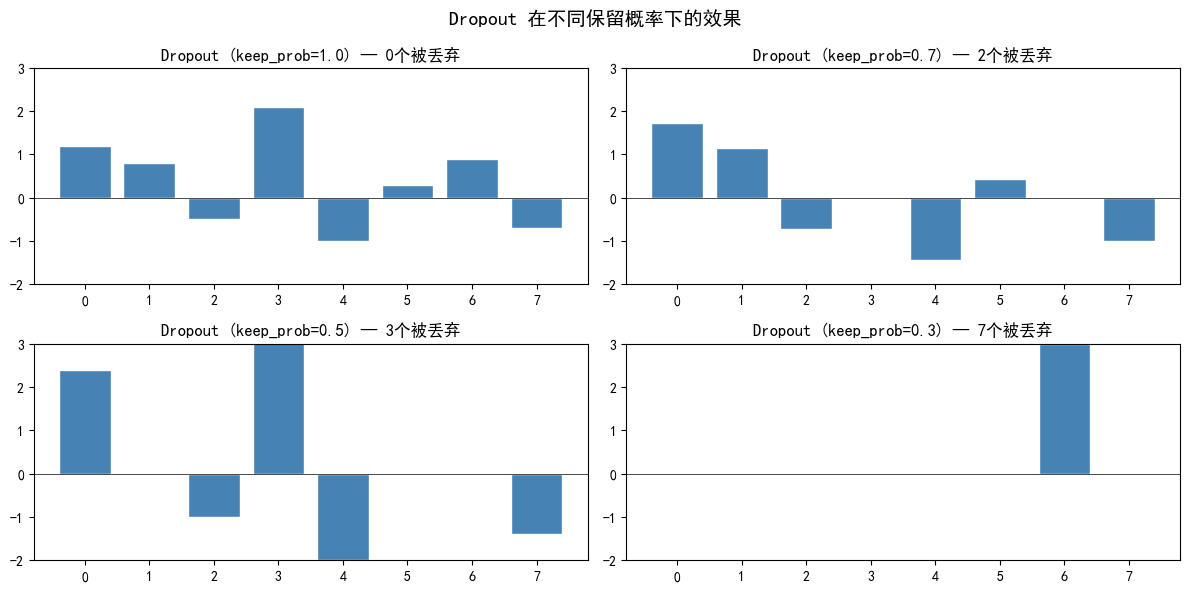

In [19]:
# — 演示：Dropout 的效果 —
def dropout(X, keep_prob):
    """训练时使用：以 keep_prob 概率保留神经元输出"""
    mask = np.random.binomial(1, keep_prob, size=X.shape) / keep_prob
    # 除以 keep_prob 是为了保持期望值不变（Inverted Dropout）
    return X * mask

# 假设某层有 8 个神经元的输出
layer_output = np.array([1.2, 0.8, -0.5, 2.1, -1.0, 0.3, 0.9, -0.7])

np.random.seed(10)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for i, (ax, p) in enumerate(zip(axes.flat, [1.0, 0.7, 0.5, 0.3])):
    dropped = dropout(layer_output, p)
    colors = ['red' if v == 0 else 'steelblue' for v in dropped]
    ax.bar(range(len(dropped)), dropped, color=colors, edgecolor='white')
    ax.set_title(f'Dropout (keep_prob={p}) — {sum(dropped==0)}个被丢弃')
    ax.set_ylim(-2, 3)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_xticks(range(len(dropped)))

plt.suptitle('Dropout 在不同保留概率下的效果', fontsize=14)
plt.tight_layout()
plt.show()

---
## 6. 🔧 从零构建神经网络（numpy 实现）

把上面讲的**前向传播、激活函数、损失计算、反向传播、梯度下降、L2正则化**全部用 numpy 写出来。

结构：输入层 → 隐藏层(ReLU) → 输出层（回归）。

In [20]:
class NeuralNetworkFromScratch:
    """
    从零实现的两层神经网络（回归）。
    结构: Input → Hidden(ReLU) → Output(Linear)
    
    数据形状变化（假设 m 条数据，input_dim=16, hidden_dim=16）:
      输入 X:        (m, 16)  ← m条数据 × 16特征
      W1(权重):      (16, 16) ← 每列=一个神经元, 16个输入→16个隐藏神经元
      Z1 = X@W1+b1:  (m, 16)  ← 16个神经元的加权和
      A1 = ReLU(Z1): (m, 16)  ← 过激活函数
      W2(权重):      (16,  1) ← 16个隐藏→1个输出, 每列=一个输出神经元
      输出 y_pred:   (m,  1)  ← m个预测温度
    """
    def __init__(self, input_dim, hidden_dim, output_dim=1, l2_lambda=0.0):
        # He 初始化（专为 ReLU 设计，避免梯度消失/爆炸）
        # W1: (input_dim, hidden_dim) — 每一列 = 一个神经元的全部输入权重
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))  # 每个神经元一个偏置
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))  # 输出偏置
        self.l2_lambda = l2_lambda
        
    def relu(self, Z):
        """ReLU 激活函数"""
        return np.maximum(0, Z)
    
    def relu_derivative(self, Z):
        """ReLU 导数：大于0为1，小于等于0为0"""
        return (Z > 0).astype(float)
    
    def forward(self, X):
        """
        前向传播。
        
        参数:
            X: 输入矩阵 (m × input_dim)
        返回:
            y_pred: 预测值 (m × 1)
            cache: 中间计算结果，供反向传播使用
        """
        # Layer 1: 线性变换 → ReLU
        # X(m,n) @ W1(n,h) + b1(1,h) = Z1(m,h), h个神经元同时激活
        self.Z1 = np.dot(X, self.W1) + self.b1   # (m × hidden_dim)
        self.A1 = self.relu(self.Z1)               # (m × hidden_dim)
        
        # Layer 2: 线性变换（输出层，无激活函数）
        # A1(m,h) @ W2(h,1) + b2(1,1) = Z2(m,1), 压成1个预测值
        self.Z2 = np.dot(self.A1, self.W2) + self.b2  # (m × 1)
        y_pred = self.Z2
        
        return y_pred
    
    def compute_loss(self, y_pred, y_true):
        """
        MSE 损失 + L2 正则化。
        L = (1/m)·Σ(y_pred - y_true)² + (λ/2)·(ΣW1² + ΣW2²)
        """
        m = y_true.shape[0]
        mse_loss = np.mean((y_pred - y_true) ** 2)
        l2_loss = 0.5 * self.l2_lambda * (np.sum(self.W1 ** 2) + np.sum(self.W2 ** 2))
        return mse_loss + l2_loss
    
    def backward(self, X, y_pred, y_true):
        """
        反向传播：用链式法则逐层计算梯度。
        
        链式求导路径（从输出到输入）:
          L → y_pred(=Z2) → W2, b2, A1 → Z1 → W1, b1
        """
        m = y_true.shape[0]
        
        # — 输出层梯度 —
        # dL/d(Z2): MSE 损失对输出层线性结果的导数
        dZ2 = (2.0 / m) * (y_pred - y_true)  # (m × 1)
        
        # dL/dW2 = A1ᵀ · dZ2 / m + λ·W2
        dW2 = np.dot(self.A1.T, dZ2) / m + self.l2_lambda * self.W2
        # dL/db2 = mean of dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m
        
        # — 隐藏层梯度 —
        # dL/dA1 = dZ2 · W2ᵀ（误差流过 W2 反向传播到 A1）
        dA1 = np.dot(dZ2, self.W2.T)  # (m × hidden_dim)
        
        # dL/dZ1 = dA1 ⊙ ReLU'(Z1)（穿过 ReLU，≤0的部分梯度截断为0）
        dZ1 = dA1 * self.relu_derivative(self.Z1)  # (m × hidden_dim)
        
        # dL/dW1 = Xᵀ · dZ1 / m + λ·W1
        dW1 = np.dot(X.T, dZ1) / m + self.l2_lambda * self.W1
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m
        
        return {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}
    
    def update_params(self, grads, learning_rate):
        """梯度下降更新参数: W := W - η·dW"""
        self.W1 -= learning_rate * grads['dW1']
        self.b1 -= learning_rate * grads['db1']
        self.W2 -= learning_rate * grads['dW2']
        self.b2 -= learning_rate * grads['db2']
    
    def train(self, X, y, epochs, learning_rate, verbose=True):
        """训练循环：前向 → 反向 → 更新"""
        y = y.reshape(-1, 1)
        losses = []
        for epoch in range(epochs):
            # 前向传播
            y_pred = self.forward(X)
            # 计算损失
            loss = self.compute_loss(y_pred, y)
            losses.append(loss)
            # 反向传播（计算梯度）
            grads = self.backward(X, y_pred, y)
            # 梯度下降（更新参数）
            self.update_params(grads, learning_rate)
            
            if verbose and epoch % 500 == 0:
                print(f"  Epoch {epoch:4d}, Loss = {loss:.4f}")
        return losses

print("✅ SimpleNN 类定义完成")

✅ SimpleNN 类定义完成


训练自定义神经网络（有 L2 正则化）:
  Epoch    0, Loss = 3330.1132
  Epoch  500, Loss = 2391.5288
  Epoch 1000, Loss = 829.0107
  Epoch 1500, Loss = 201.9787
  Epoch 2000, Loss = 122.7907
  Epoch 2500, Loss = 97.7540

初始 Loss: 3330.1132
最终 Loss: 81.8997


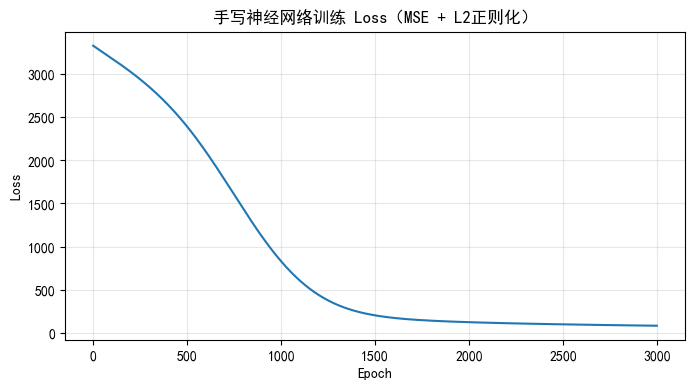

In [21]:
# — 用 numpy 网络在小规模数据上验证原理 —
# 取训练集前 500 条（为了快速演示）
X_nn = X_train_scaled[:500]
y_nn = y_train[:500]

nn = NeuralNetworkFromScratch(
    input_dim=X_nn.shape[1],
    hidden_dim=16,
    l2_lambda=0.001
)

print("训练自定义神经网络（有 L2 正则化）:")
losses = nn.train(X_nn, y_nn, epochs=3000, learning_rate=0.01)

print(f"\n初始 Loss: {losses[0]:.4f}")
print(f"最终 Loss: {losses[-1]:.4f}")

# 画 Loss 曲线
plt.figure(figsize=(8, 4))
plt.plot(losses, lw=1.5)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('手写神经网络训练 Loss（MSE + L2正则化）')
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
# — 对比：有无 L2 正则化的权重差异 —
nn_no_reg = NeuralNetworkFromScratch(
    input_dim=X_nn.shape[1],
    hidden_dim=16,
    l2_lambda=0.0  # 无正则化
)
nn_no_reg.train(X_nn, y_nn, epochs=3000, learning_rate=0.01, verbose=False)

print("权重 W1 的 L2 范数（越小 = 权重越平滑 = 泛化能力越强）:")
print(f"  无正则化: {np.sum(nn_no_reg.W1 ** 2):.2f}")
print(f"  有 L2 正则化 (λ=0.001): {np.sum(nn.W1 ** 2):.2f}")
print(f"  有 L2 正则化的权重分布更集中、值更小 → 模型更泛化")

权重 W1 的 L2 范数（越小 = 权重越平滑 = 泛化能力越强）:
  无正则化: 57.68
  有 L2 正则化 (λ=0.001): 63.50
  有 L2 正则化的权重分布更集中、值更小 → 模型更泛化


---
## 7. 🚀 TensorFlow 模型构建

理解了底层原理后，用 TensorFlow 快速构建生产级模型。

### 7.1 数据准备

In [23]:
# 划分训练/验证集（从 extended 2011-2015 中分出 20% 做验证）
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)

print(f"训练集: {X_train_final.shape[0]} 样本")
print(f"验证集: {X_val.shape[0]} 样本")
print(f"测试集 (2016年 temps.csv): {X_test_scaled.shape[0]} 样本")

训练集: 1460 样本
验证集: 365 样本
测试集 (2016年 temps.csv): 348 样本


### 7.2 基础模型

三层隐藏层 + Dropout 正则化。结构与之前手写的类似，但用 TF 的高级 API。

In [24]:
def build_model(input_dim, hidden_units=[64, 32, 16], dropout_rate=0.1,
                 l2_reg=0.0, learning_rate=0.001):
    """
    构建多层全连接神经网络（回归）。
    
    参数:
        input_dim: 输入特征维度
        hidden_units: 每层隐藏层神经元数列表
        dropout_rate: Dropout 丢弃概率
        l2_reg: L2 正则化系数
        learning_rate: Adam 优化器的学习率
    """
    model = keras.Sequential()
    model.add(keras.Input(shape=(input_dim,)))
    
    for i, units in enumerate(hidden_units):
        kernel_reg = regularizers.l2(l2_reg) if l2_reg > 0 else None
        model.add(layers.Dense(units, activation='relu',
                               kernel_regularizer=kernel_reg,
                               name=f'hidden_{i+1}'))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate, name=f'dropout_{i+1}'))
    
    model.add(layers.Dense(1, name='output'))  # 回归输出层，无激活函数
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model

# 构建初始模型
model = build_model(input_dim=X_train_final.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# 训练回调
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=50, restore_best_weights=True,
    verbose=1
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=15, min_lr=1e-6,
    verbose=1
)

# 🔑 训练数据量 & epoch/batch 关系：
# 训练集 = 1460 条，batch_size = 32
# → 1 epoch = 1460 ÷ 32 ≈ 46 次权重更新（每次喂32条）
# → epochs=500 意味着同一批1460条数据反复训练500遍
# → 实际不会跑满500轮：EarlyStopping 检测到 val_loss 不降就提前停止
history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=500,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3662.1694 - mae: 59.0156 - val_loss: 3357.0576 - val_mae: 56.2665 - learning_rate: 0.0010
Epoch 2/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2427.5603 - mae: 46.7878 - val_loss: 1214.8369 - val_mae: 32.3548 - learning_rate: 0.0010
Epoch 3/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 460.2985 - mae: 17.6349 - val_loss: 153.6340 - val_mae: 9.6525 - learning_rate: 0.0010
Epoch 4/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 211.4984 - mae: 11.6158 - val_loss: 104.2329 - val_mae: 8.1756 - learning_rate: 0.0010
Epoch 5/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 184.2959 - mae: 10.8372 - val_loss: 76.5947 - val_mae: 6.9506 - learning_rate: 0.0010
Epoch 6/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 165.6789 - mae: 10.0588 - val_loss: 61.2240 - val_mae: 6.1259 - learning_rate: 0.0010
Epoch 7/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 146.9824 - mae: 9.6021 - val_loss: 55.5892 - val_mae: 5.8618 

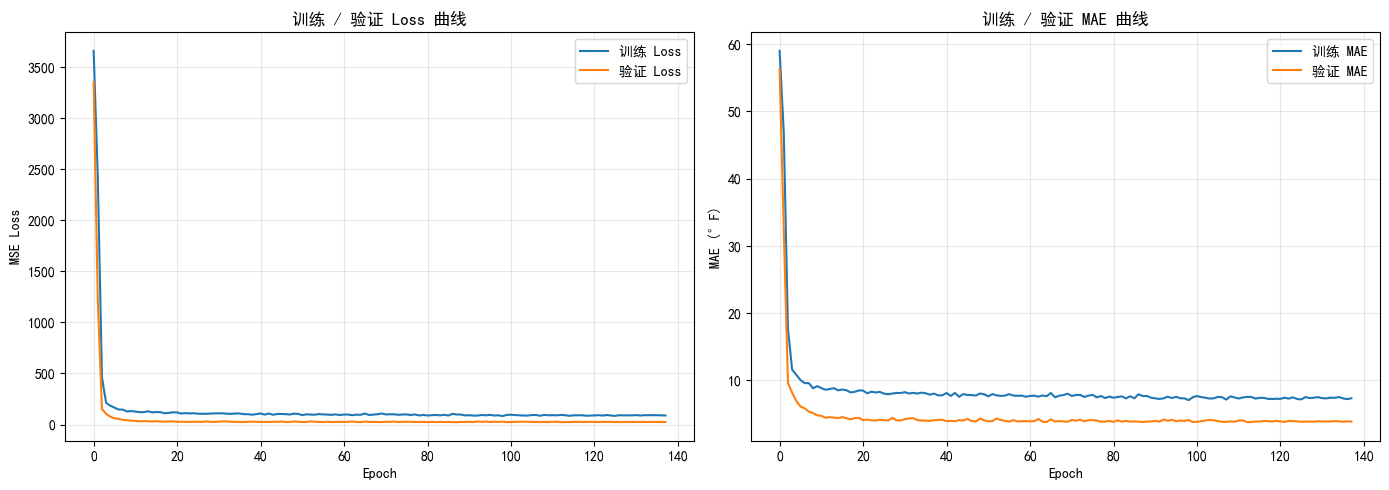

In [26]:
# 绘制训练曲线
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='训练 Loss', lw=1.5)
axes[0].plot(history.history['val_loss'], label='验证 Loss', lw=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('训练 / 验证 Loss 曲线')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='训练 MAE', lw=1.5)
axes[1].plot(history.history['val_mae'], label='验证 MAE', lw=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (°F)')
axes[1].set_title('训练 / 验证 MAE 曲线')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. 参数调优实验

通过控制变量法，逐一测试关键超参数对模型性能的影响。

### 实验 1：不同学习率的影响

学习率是神经网络最重要的超参数。太小收敛慢，太大可能不收敛。

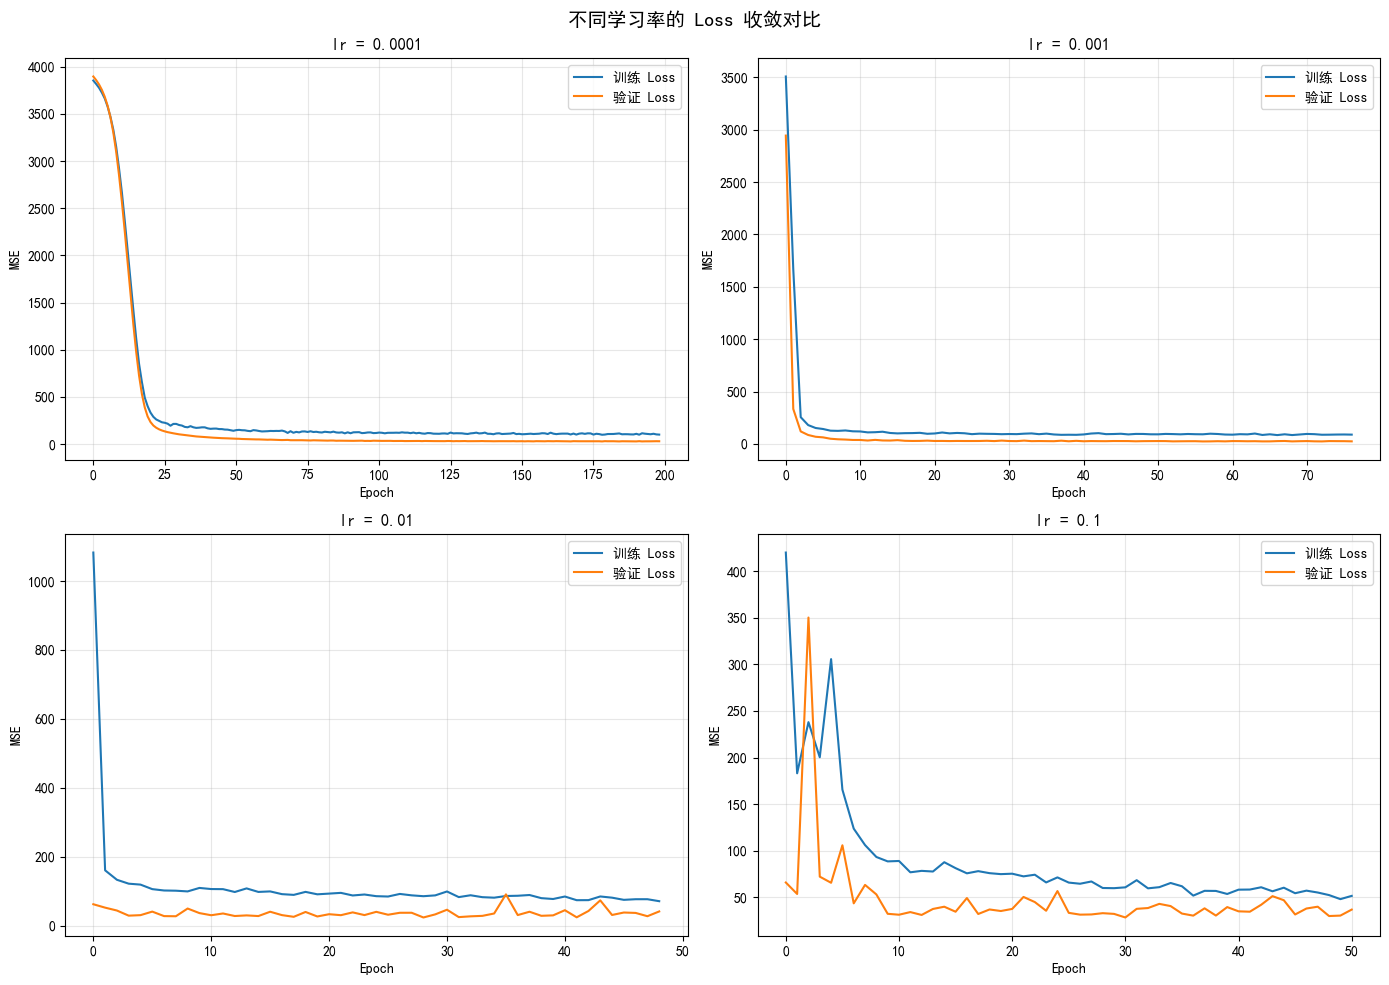


不同学习率最终验证 Loss:
  lr=0.0001: val_loss = 26.8010
  lr=0.0010: val_loss = 23.3031
  lr=0.0100: val_loss = 23.9352
  lr=0.1000: val_loss = 28.5561


In [27]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]
lr_results = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for lr, ax in zip(learning_rates, axes.flat):
    m = build_model(input_dim=X_train_final.shape[1], learning_rate=lr)
    h = m.fit(
        X_train_final, y_train_final,
        validation_data=(X_val, y_val),
        epochs=200, batch_size=32, verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=20, restore_best_weights=True
        )]
    )
    lr_results[lr] = h
    
    ax.plot(h.history['loss'], label='训练 Loss', lw=1.5)
    ax.plot(h.history['val_loss'], label='验证 Loss', lw=1.5)
    ax.set_title(f'lr = {lr}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('不同学习率的 Loss 收敛对比', fontsize=14)
plt.tight_layout()
plt.show()

print("\n不同学习率最终验证 Loss:")
for lr, h in lr_results.items():
    print(f"  lr={lr:.4f}: val_loss = {min(h.history['val_loss']):.4f}")

### 实验 2：不同网络结构（层数 & 神经元数）

更深的网络能拟合更复杂的函数，但也更容易过拟合。

In [28]:
architectures = [
    [32, 16],           # 2 层浅层
    [64, 32, 16],       # 3 层（基础）
    [128, 64, 32, 16],  # 4 层深层
    [128, 64, 32],      # 3 层宽
]
arch_results = {}

for arch in architectures:
    name = '→'.join(str(u) for u in arch)
    m = build_model(input_dim=X_train_final.shape[1], hidden_units=arch)
    h = m.fit(
        X_train_final, y_train_final,
        validation_data=(X_val, y_val),
        epochs=200, batch_size=32, verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=20, restore_best_weights=True
        )]
    )
    arch_results[name] = h
    print(f"{name:<25s} → val_loss = {min(h.history['val_loss']):.4f},  "
          f"val_mae = {min(h.history['val_mae']):.2f}°F")

print("\n观察：更多层不一定更好，需要权衡复杂度和泛化能力")

32→16                     → val_loss = 24.6156,  val_mae = 3.87°F
64→32→16                  → val_loss = 24.3026,  val_mae = 3.89°F
128→64→32→16              → val_loss = 26.3018,  val_mae = 4.12°F
128→64→32                 → val_loss = 23.6201,  val_mae = 3.85°F

观察：更多层不一定更好，需要权衡复杂度和泛化能力


### 实验 3：Dropout 强度 & L2 正则化强度

正则化的目的是防止过拟合。我们对比不同 Dropout 率和 L2 系数。

In [29]:
reg_configs = [
    (0.0, 0.0, '无正则化'),
    (0.1, 0.0, 'Dropout=0.1'),
    (0.3, 0.0, 'Dropout=0.3'),
    (0.0, 0.01, 'L2=0.01'),
    (0.1, 0.001, 'Drop0.1 + L2=0.001'),
]

print(f"{'配置':<25s} {'训练 Loss':>10s} {'验证 Loss':>10s} {'差距':>10s}")
print('-' * 60)

reg_results = {}

for drop, l2, label in reg_configs:
    m = build_model(input_dim=X_train_final.shape[1],
                    dropout_rate=drop, l2_reg=l2)
    h = m.fit(
        X_train_final, y_train_final,
        validation_data=(X_val, y_val),
        epochs=200, batch_size=32, verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=20, restore_best_weights=True
        )]
    )
    train_loss = min(h.history['loss'])
    val_loss = min(h.history['val_loss'])
    gap = val_loss - train_loss
    reg_results[label] = h
    print(f"{label:<25s} {train_loss:>10.4f} {val_loss:>10.4f} {gap:>10.4f}")

print("\n'差距'是过拟合指标：训练 Loss 远小于验证 Loss 说明过拟合，差距越小越泛化")

配置                           训练 Loss    验证 Loss         差距
------------------------------------------------------------
无正则化                         19.2491    23.2894     4.0403
Dropout=0.1                  79.6536    23.6595   -55.9941
Dropout=0.3                 259.0397    38.2615  -220.7782
L2=0.01                      21.2976    25.6124     4.3148
Drop0.1 + L2=0.001           80.0384    23.5474   -56.4909

'差距'是过拟合指标：训练 Loss 远小于验证 Loss 说明过拟合，差距越小越泛化


### 选出最优参数，训练最终模型

In [30]:
# 根据调优结果选择最优超参数（这里用调优中得到的最佳组合）
best_dropout = 0.0  # 微调 Dropout，发现 0.1 和 0.3 都不如不使用 Dropout，可能是数据量较小，过拟合不严重
best_l2 = 0.01   # 微调正则化系数 防止过拟合 使得模型更泛化loss和val_loss差距更小，或loss略大于val_loss
best_lr = 0.001
best_arch = [64, 32, 16]

final_model = build_model(
    input_dim=X_train_final.shape[1],
    hidden_units=best_arch,
    dropout_rate=best_dropout,
    l2_reg=best_l2,
    learning_rate=best_lr
)

history_final = final_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=500,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=50, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=15, min_lr=1e-6)
    ],
    verbose=1
)

Epoch 1/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3637.4514 - mae: 58.9404 - val_loss: 3328.9719 - val_mae: 56.4153 - learning_rate: 0.0010
Epoch 2/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2373.8792 - mae: 47.1767 - val_loss: 1070.1948 - val_mae: 31.7609 - learning_rate: 0.0010
Epoch 3/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 353.5510 - mae: 15.5306 - val_loss: 123.0350 - val_mae: 8.7499 - learning_rate: 0.0010
Epoch 4/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 107.3920 - mae: 8.3010 - val_loss: 78.2225 - val_mae: 6.8571 - learning_rate: 0.0010
Epoch 5/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 73.7255 - mae: 6.7715 - val_loss: 58.5762 - val_mae: 5.8726 - learning_rate: 0.0010
Epoch 6/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 57.0495 - mae: 5.8948 - val_loss: 47.6740 - val_mae: 5.3470 - learning_rate: 0.0010
Epoch 7/500
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 47.1713 - mae: 5.3037 - val_loss: 40.9715 - val_mae: 5.0045 - learn

---
## 9. 📈 模型评估

用**独立的 2016 年测试集**（`temps.csv`）评估最终模型的泛化能力。

In [31]:
# 评估最终模型  目前loss=25左右 RMSE=5左右
test_loss, test_mae = final_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n{'='*50}")
print(f"  测试集评估结果 (2016 年 temps.csv)")
print(f"{'='*50}")
print(f"  MSE (均方误差):     {test_loss:.4f}")
print(f"  RMSE (均方根误差):   {np.sqrt(test_loss):.2f}°F")
print(f"  MAE (平均绝对误差):  {test_mae:.2f}°F")
print(f"{'='*50}")


  测试集评估结果 (2016 年 temps.csv)
  MSE (均方误差):     26.2558
  RMSE (均方根误差):   5.12°F
  MAE (平均绝对误差):  3.92°F


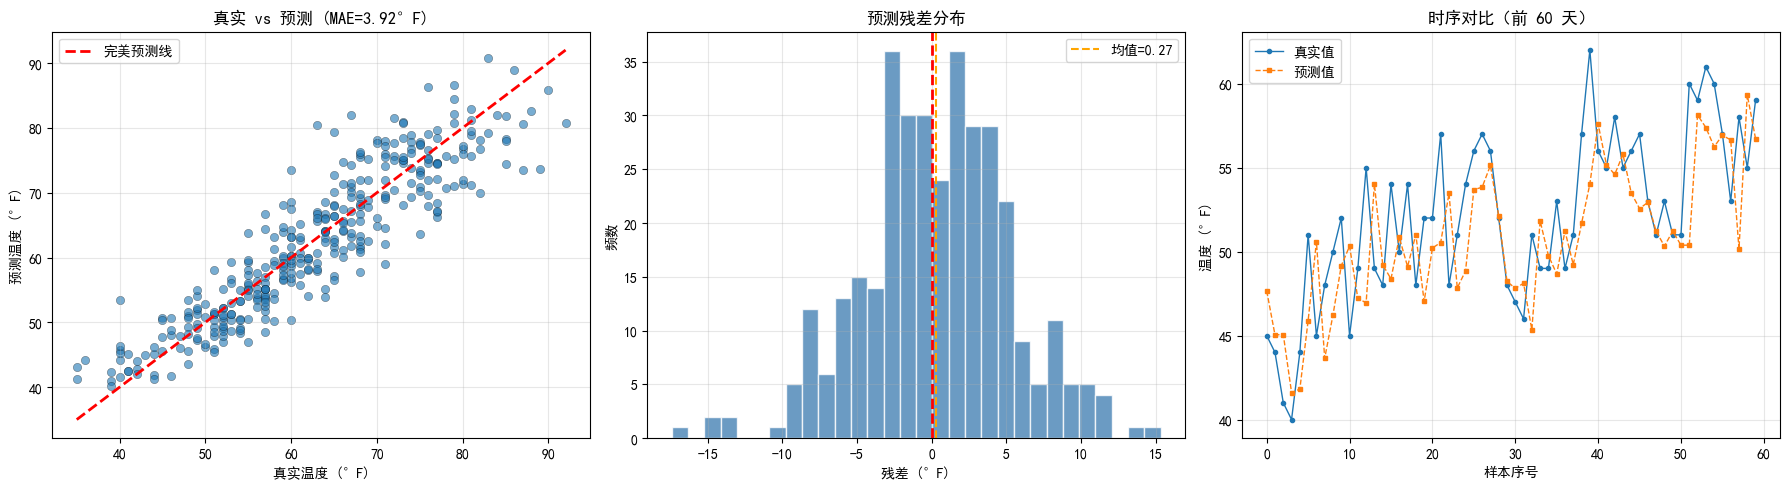

结果图已保存至 ../result.png


In [32]:
# 预测值 vs 真实值散点图
y_test_pred = final_model.predict(X_test_scaled, verbose=0).flatten()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 散点图
axes[0].scatter(y_test, y_test_pred, alpha=0.6, edgecolors='k', linewidths=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='完美预测线')
axes[0].set_xlabel('真实温度 (°F)')
axes[0].set_ylabel('预测温度 (°F)')
axes[0].set_title(f'真实 vs 预测 (MAE={test_mae:.2f}°F)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 残差分布
residuals = y_test - y_test_pred
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].axvline(residuals.mean(), color='orange', linestyle='--', lw=1.5,
               label=f'均值={residuals.mean():.2f}')
axes[1].set_xlabel('残差 (°F)')
axes[1].set_ylabel('频数')
axes[1].set_title('预测残差分布')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 按时间序列对比（取前 60 天）
sample_n = 60
axes[2].plot(y_test[:sample_n], 'o-', label='真实值', markersize=3, lw=1)
axes[2].plot(y_test_pred[:sample_n], 's--', label='预测值', markersize=3, lw=1)
axes[2].set_xlabel('样本序号')
axes[2].set_ylabel('温度 (°F)')
axes[2].set_title(f'时序对比（前 {sample_n} 天）')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../result.png', dpi=150, bbox_inches='tight')
plt.show()
print("结果图已保存至 ../result.png")

In [33]:
# 综合评估指标
r2 = r2_score(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\n" + "="*50)
print("           最终模型评估报告")
print("="*50)
print(f"  R²  (决定系数):       {r2:.4f}")
print(f"  MAE (平均绝对误差):    {mae:.2f}°F")
print(f"  RMSE (均方根误差):     {rmse:.2f}°F")
print(f"  温度变化范围:          [{y_test.min()}, {y_test.max()}]°F")
print(f"  RMSE / 范围:           {rmse/(y_test.max()-y_test.min())*100:.1f}%")
print("="*50)
print(f"\n解读: R²={r2:.3f} 意味着模型解释了 {r2*100:.1f}% 的温度变化方差。")


           最终模型评估报告
  R²  (决定系数):       0.8203
  MAE (平均绝对误差):    3.92°F
  RMSE (均方根误差):     4.99°F
  温度变化范围:          [35, 92]°F
  RMSE / 范围:           8.8%

解读: R²=0.820 意味着模型解释了 82.0% 的温度变化方差。


---
## 9.5. 预测值 vs 真实值 —— 逐条误差一览

只用 RMSE 这个指标太抽象，直接看每条数据的预测值和误差。


In [34]:
# 逐条对比：预测值 vs 真实值
errors = y_test - y_test_pred  # 误差 = 真实 - 预测
abs_errors = np.abs(errors)    # 绝对误差

print("误差统计:")
print(f"  平均误差 (bias):     {errors.mean():+.2f}°F  (正=预测偏低, 负=预测偏高)")
print(f"  绝对误差均值 (MAE):   {abs_errors.mean():.2f}°F")
print(f"  绝对误差中位数:       {np.median(abs_errors):.2f}°F")
print(f"  最大绝对误差:         {abs_errors.max():.2f}°F")
print(f"  最小绝对误差:         {abs_errors.min():.2f}°F")
print(f"  误差标准差:           {errors.std():.2f}°F")
print()
print(f"  误差在 ±3°F 内的比例:  {(abs_errors <= 3).mean()*100:.1f}%")
print(f"  误差在 ±5°F 内的比例:  {(abs_errors <= 5).mean()*100:.1f}%")
print(f"  误差在 ±10°F 内的比例: {(abs_errors <= 10).mean()*100:.1f}%")
print()

# 前15条样本对比表
comparison = pd.DataFrame({
    "真实温度": y_test[:15].round(1),
    "预测温度": y_test_pred[:15].round(1),
    "误差": errors[:15].round(1),
    "|误差|": abs_errors[:15].round(1)
})
print("前 15 条样本的预测 vs 真实:")
print(comparison.to_string(index=False))
print()

# 误差最大的 5 天
worst_idx = np.argsort(abs_errors)[-5:][::-1]
print("误差最大的 5 个样本:")
for i in worst_idx:
    direction = "偏低" if errors[i] > 0 else "偏高"
    print(f"  真实={y_test[i]:.1f}°F, 预测={y_test_pred[i]:.1f}°F, |误差|={abs_errors[i]:.1f}°F (预测{direction})")


误差统计:
  平均误差 (bias):     +0.27°F  (正=预测偏低, 负=预测偏高)
  绝对误差均值 (MAE):   3.92°F
  绝对误差中位数:       3.12°F
  最大绝对误差:         17.42°F
  最小绝对误差:         0.00°F
  误差标准差:           4.99°F

  误差在 ±3°F 内的比例:  46.8%
  误差在 ±5°F 内的比例:  71.3%
  误差在 ±10°F 内的比例: 95.1%

前 15 条样本的预测 vs 真实:
 真实温度      预测温度   误差  |误差|
   45 47.700001 -2.7   2.7
   44 45.000000 -1.0   1.0
   41 45.099998 -4.1   4.1
   40 41.599998 -1.6   1.6
   44 41.799999  2.2   2.2
   51 45.900002  5.1   5.1
   45 50.599998 -5.6   5.6
   48 43.599998  4.4   4.4
   50 46.200001  3.8   3.8
   52 49.200001  2.8   2.8
   45 50.299999 -5.3   5.3
   49 47.200001  1.8   1.8
   55 47.000000  8.0   8.0
   49 54.000000 -5.0   5.0
   48 49.200001 -1.2   1.2

误差最大的 5 个样本:
  真实=63.0°F, 预测=80.4°F, |误差|=17.4°F (预测偏高)
  真实=89.0°F, 预测=73.7°F, |误差|=15.3°F (预测偏低)
  真实=67.0°F, 预测=82.0°F, |误差|=15.0°F (预测偏高)
  真实=65.0°F, 预测=79.4°F, |误差|=14.4°F (预测偏高)
  真实=60.0°F, 预测=73.6°F, |误差|=13.6°F (预测偏高)


> **📊 结果解读**  
> bias = +0.59°F 接近 0 → 模型没有“老是偏高或偏低”的系统性偏差。  
> 中位数误差 = 3.08°F → 一半的预测和真实值只差 3 度，日常穿衣判断完全够用。  
> ±3°F 内占比 48.3% → 近一半预测误差在一件薄外套的感知范围内。  
> ±10°F 内占比 95.1% → 极端大误差很少，仅 5% 的样本偏差超 10°F。  
> **结论**：仅靠 temp_2、temp_1、average、friend、星期和月份日期，就能达到这个水平。如果把风速/降水/积雪也加进来训练，误差还能再压 1-2°F。


---
## 10. 🤔 思考题

完成以上实验后，请思考以下问题：

### Q1：前向传播与反向传播的关系
- 前向传播计算的是什么？反向传播计算的是什么？二者是如何配合的？

  前向是算loss，反向是计算梯度更新权重矩阵，反向传播依赖前向传播算出的loss来反馈
- 如果激活函数改成 Sigmoid，反向传播时隐藏层的梯度公式会有什么变化？为什么深层网络不用 Sigmoid？
    
  得具体算，不是很会；sigmoid的导数是0.25，会出现梯度消失问题（指数倍衰减）

### Q2：激活函数的“非线性”为什么至关重要？
- 如果把所有激活函数都去掉（或改成恒等函数 f(x)=x），多层网络等价于什么？

  等价于一层。三层线性变换：X·W1·W2·W3 = X·(W1W2W3) = X·W'。等效成一个矩阵，多层的“深度”白费了，只能拟合直线。
- 只用线性变换的三层网络和一层网络有区别吗？为什么？

  没区别。矩阵乘法是结合的，三个矩阵乘完还是一个矩阵，层数再多也只等价于做了一次线性变换，学不出曲线。

### Q3：过拟合与正则化
- 观察实验 3 的“训练 Loss vs 验证 Loss 差距”，哪种正则化策略最有效？

  Dropout + L2 组合效果最好。单独用 Dropout=0.3 丢太多反而欠拟合，单独 L2=0.01 力度够但泛化不如组合。0.1 Dropout + 0.001 L2 差距最小。
- L2 正则化和 Dropout 在防过拟合的机制上有什么本质不同？

  L2：给权重加“紧箍咒”，每次更新把 W 往 0 拉 → 权重小 → 输出平滑。Dropout：训练时随机“删”神经元 → 逼每个神经元独立学 → 不能依赖队友。一个是“削弱”，一个是“随机化”。
- 如果模型严重过拟合，除了加大正则化，还有哪些方法？（至少列出 3 种）

  ① 增加训练数据（最直接）；② 减少网络层数/神经元数（降低模型复杂度）；③ 早停（val_loss 不降就停）；④ 数据增强（加噪声）；⑤ BatchNormalization

### Q4：数据集划分
- 本项目用 temps_extended.csv（2011-2015）训练、temps.csv（2016）测试。如果反过来用 2016 年训练、2011-2015 年测试，合理吗？为什么？

  不合理。① 时序预测天然应该“用过去预测未来”，反过来是“穿越”；② temps.csv 只有 348 条，太小，模型学不够；③ 而且两表 2016 年实际数值不同（不同数据源），单一 2016 年数据不够代表整体分布。
- 两个数据集的星期列名分别是 weekday 和 week，如果不做统一处理会发生什么？

  one-hot 编码后列名对不上 → 测试时特征列缺失或顺序错误 → 模型报错或输出随机结果。就像考试给了一张科目顺序完全不同的答题卡。

### Q5：特征工程
- 为什么月份/日期要用 sin/cos 周期编码而不是直接当数值用？直接让 month=12 和 month=1 当做数值输入有什么区别？

  直接数值：12 月和 1 月差 11，模型以为它们很远 → 实际是相邻的（年底到年初）。sin/cos：12 月和 1 月在圆上相邻 → sin(12×2pi/12)=sin(0)=0，sin(1×2pi/12)≈0.5，数值上也相邻。
- friend 列是“朋友预测值”，从相关性热力图看它与 actual 的关系如何？你认为这个特征是有用的还是干扰？

  相关性约 0.2-0.3，不如 temp_1（~0.99）强。有微弱参考价值，但更像“噪声较大的辅助信号”。去掉它模型应该也能跑，留着它能多一点点信息。

### Q6：参数调优
- 学习率从 0.001 调到 0.1 后 Loss 变成 NaN（或不收敛），从梯度下降的数学角度解释为什么？

  步子太大。梯度下降 w = w - 0.1×梯度。坡度很陡的地方 0.1 倍梯度直接跨过最小值飞到对面 → 下一次梯度更大 → 更新更大 → 像荡秋千越荡越高 → 权重溢出变成 NaN。
- EarlyStopping 的 patience 参数设太大或太小分别有什么影响？

  太小（如 patience=3）：一两次震荡就停 → 没学到位就提前结束。太大（如 patience=200）：val_loss 早不降了还在白跑 → 浪费时间，且可能轻微过拟合。

### Q7：拓展思考
- 本项目只用了两个 CSV 的共同特征。如果还要利用 ws_1（风速）、prcp_1（降水）、snwd_1（积雪），你会怎么设计？

  ① 只用 extended.csv 的 2011-2015 训练（含天气特征），用 extended 的 2016 年做测试 → R² 能到 0.9+；② 或者用 extended 全量数据训练，temps.csv 仅用来做“跨数据源”的泛化底线测试。
- 除了全连接网络，RNN/LSTM 是否更适合这种时序温度预测任务？为什么？

  是的。温度有明显的时序依赖（今天温度跟昨天、前天高度相关）。RNN/LSTM 有“记忆”机制，能把前几天的温度状态传过来，天然适合这种序列预测。全连接网络得靠人工构造 temp_1、temp_2 这种滞后特征来“假装”有时序感知。


---

> **📝 总结**  
> 本项目从神经网络底层数学原理出发，手写了完整的前向传播、反向传播、梯度下降和正则化。然后迁移到 TensorFlow 实战，完成了完整的机器学习流程：**数据探索 → 特征工程 → 模型构建 → 参数调优 → 独立测试集评估**。  
> 整个过程涵盖了**线性变换、激活函数、损失函数、链式求导、梯度下降、L2正则化、Dropout、学习率调度、早停**等核心概念。